In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.multioutput import MultiOutputRegressor
from scipy.stats import zscore
from scipy.stats.mstats import winsorize
from sklearn.feature_selection import SelectFromModel
import mlflow 


In [55]:
df=pd.read_csv("study_performance.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [56]:
df.shape

(1000, 8)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


#### gender

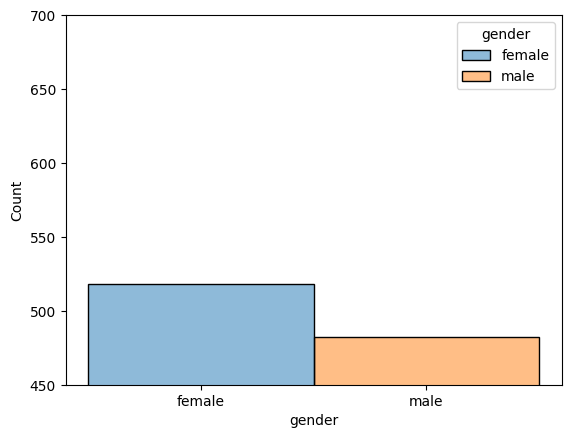

In [58]:
sns.histplot(data=df,x="gender",hue="gender")
plt.ylim(450,700)
plt.show()

#### race ethnicity depend of sex

In [59]:
female_sex=df[df["gender"]=="female"]
female_sex.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92


In [60]:
female_sex_race_ethnicity=female_sex["race_ethnicity"].value_counts()
female_sex_race_ethnicity

race_ethnicity
group C    180
group D    129
group B    104
group E     69
group A     36
Name: count, dtype: int64

In [61]:
male_sex=df[df["gender"]=="male"]
male_sex.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
10,male,group C,associate's degree,standard,none,58,54,52


In [62]:
male_sex_race_ethnicity=male_sex["race_ethnicity"].value_counts()
male_sex_race_ethnicity

race_ethnicity
group C    139
group D    133
group B     86
group E     71
group A     53
Name: count, dtype: int64

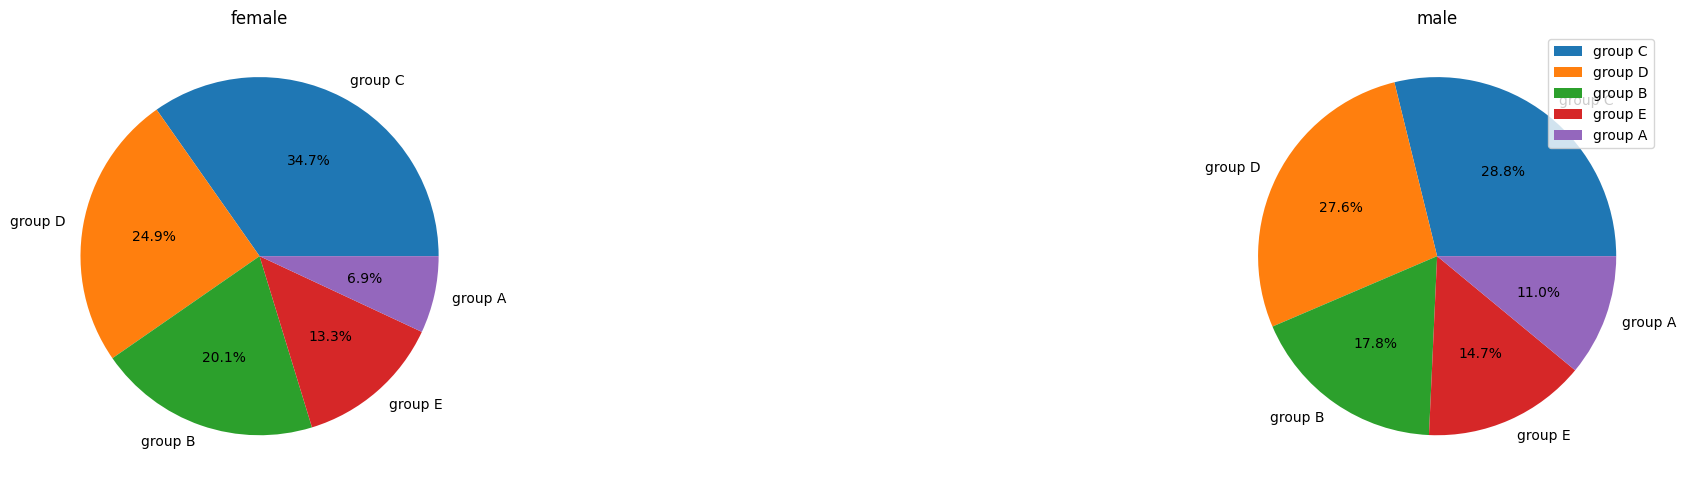

In [63]:
fig,ax=plt.subplots(1,2,figsize=(30,5))
ax[0].pie(female_sex_race_ethnicity,labels=female_sex_race_ethnicity.index,autopct='%1.1f%%')
ax[1].pie(male_sex_race_ethnicity,labels =male_sex_race_ethnicity.index,autopct='%1.1f%%')
ax[0].set_title("female")
ax[1].set_title("male")
plt.tight_layout()
plt.legend()
plt.show()

#### parental level of education depend of sex

In [64]:
male_sex=df[df["gender"]=="male"]
male_sex.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
10,male,group C,associate's degree,standard,none,58,54,52


In [65]:
male_sex_parental_level_of_education=male_sex["parental_level_of_education"].value_counts()
male_sex_parental_level_of_education

parental_level_of_education
some college          108
associate's degree    106
high school           102
some high school       88
bachelor's degree      55
master's degree        23
Name: count, dtype: int64

In [66]:
female_sex=df[df["gender"]=="female"]
female_sex.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92


In [67]:
female_sex_parental_level_of_education=female_sex["parental_level_of_education"].value_counts()
female_sex_parental_level_of_education

parental_level_of_education
some college          118
associate's degree    116
high school            94
some high school       91
bachelor's degree      63
master's degree        36
Name: count, dtype: int64

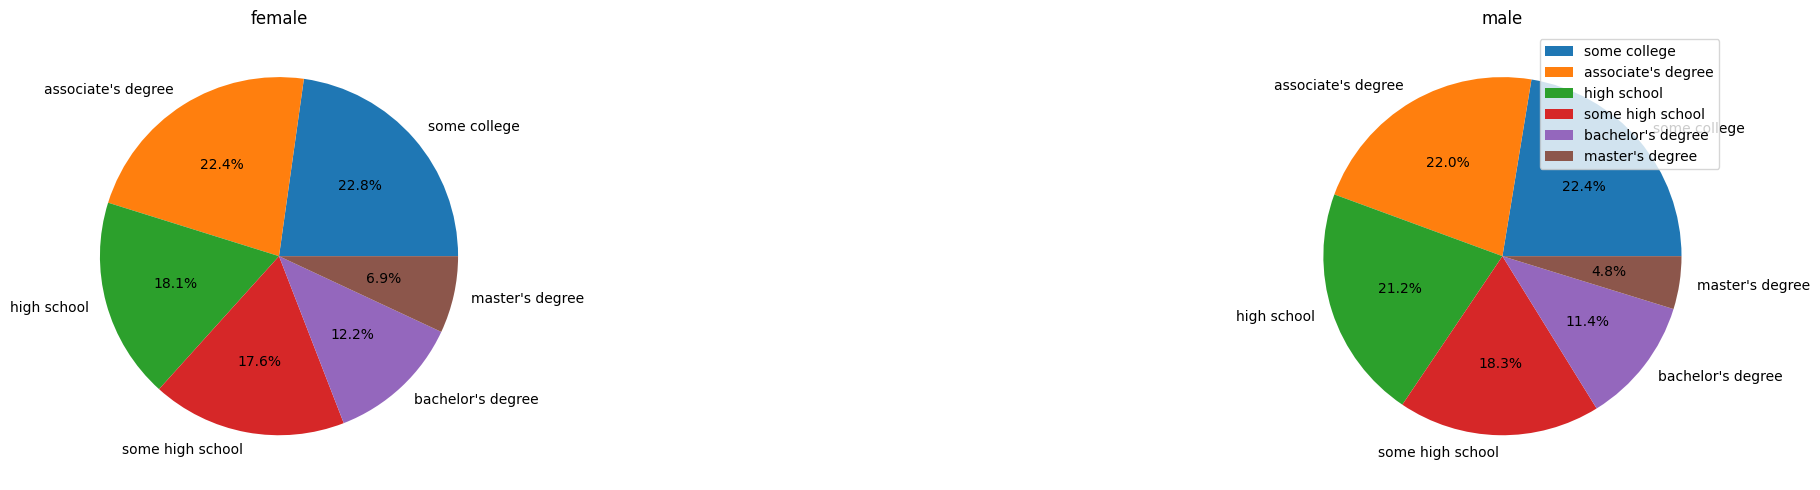

In [68]:
fig,ax=plt.subplots(1,2,figsize=(30,5))
ax[0].pie(female_sex_parental_level_of_education,labels=female_sex_parental_level_of_education.index,autopct='%1.1f%%')
ax[1].pie(male_sex_parental_level_of_education,labels =male_sex_parental_level_of_education.index,autopct='%1.1f%%')
ax[0].set_title("female")
ax[1].set_title("male")
plt.tight_layout()
plt.legend()
plt.show()

#### lunch depend of sex

In [69]:
male_sex=df[df["gender"]=="male"]
male_sex.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
10,male,group C,associate's degree,standard,none,58,54,52


In [70]:
male_sex_lunch=male_sex["lunch"].value_counts()
male_sex_lunch

lunch
standard        316
free/reduced    166
Name: count, dtype: int64

In [71]:
female_sex=df[df["gender"]=="female"]
female_sex.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92


In [72]:
female_sex_lunch=female_sex["lunch"].value_counts()
female_sex_lunch

lunch
standard        329
free/reduced    189
Name: count, dtype: int64

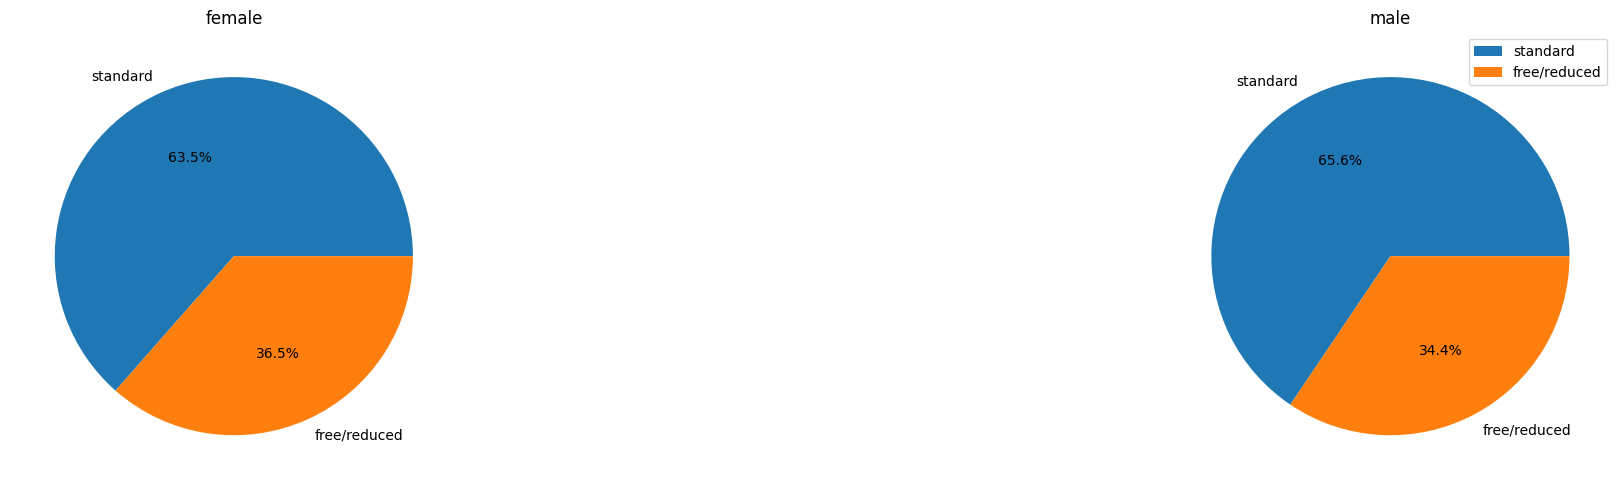

In [73]:
fig,ax=plt.subplots(1,2,figsize=(30,5))
ax[0].pie(female_sex_lunch,labels=female_sex_lunch.index,autopct='%1.1f%%')
ax[1].pie(male_sex_lunch,labels =male_sex_lunch.index,autopct='%1.1f%%')
ax[0].set_title("female")
ax[1].set_title("male")
plt.tight_layout()
plt.legend()
plt.show()

#### test preparation course depend of sex 

In [74]:
male_sex=df[df["gender"]=="male"]
male_sex.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
10,male,group C,associate's degree,standard,none,58,54,52


In [75]:
male_sex_test_preparation_course=male_sex["test_preparation_course"].value_counts()
male_sex_test_preparation_course

test_preparation_course
none         308
completed    174
Name: count, dtype: int64

In [76]:
female_sex=df[df["gender"]=="female"]
female_sex.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92


In [77]:
female_sex_test_preparation_course=female_sex["test_preparation_course"].value_counts()
female_sex_test_preparation_course

test_preparation_course
none         334
completed    184
Name: count, dtype: int64

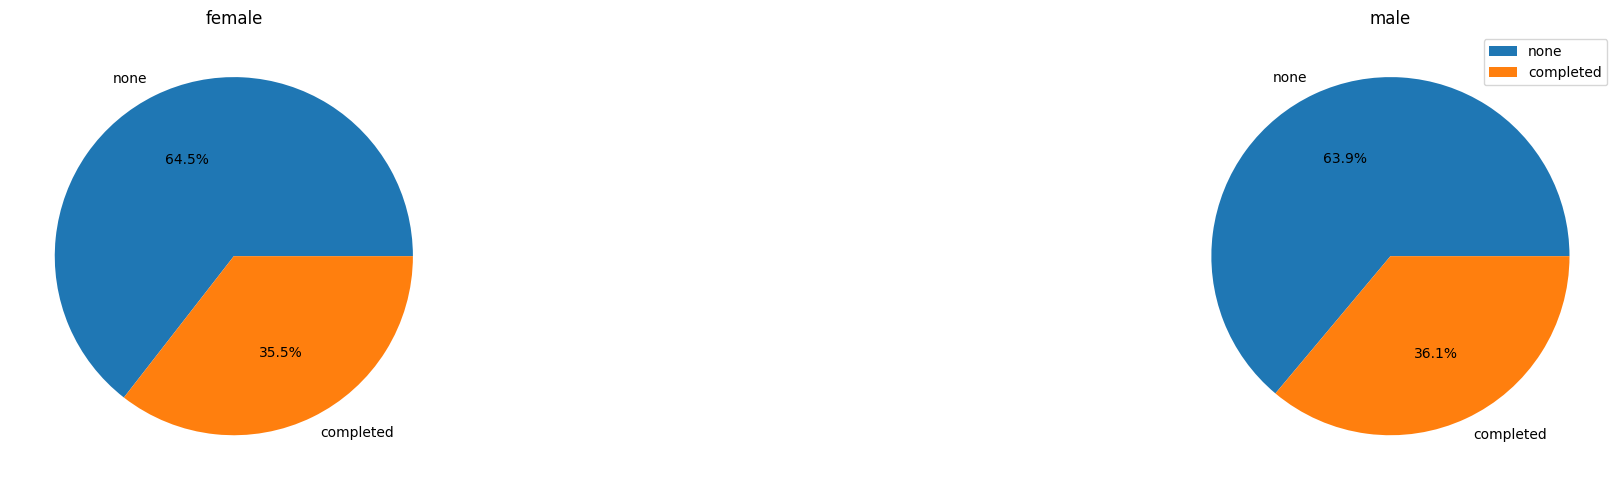

In [78]:
fig,ax=plt.subplots(1,2,figsize=(30,5))
ax[0].pie(female_sex_test_preparation_course,labels=female_sex_test_preparation_course.index,autopct='%1.1f%%')
ax[1].pie(male_sex_test_preparation_course,labels =male_sex_test_preparation_course.index,autopct='%1.1f%%')
ax[0].set_title("female")
ax[1].set_title("male")
plt.tight_layout()
plt.legend()
plt.show()

#### handle categorical feature 

In [79]:
le=LabelEncoder()
encoded_gender=le.fit_transform(df["gender"])
df.drop(columns="gender",inplace=True)
df["gender"]=encoded_gender

In [80]:
encoded_test_preparation_course=le.fit_transform(df["test_preparation_course"])
df.drop(columns="test_preparation_course",inplace=True)
df["test_preparation_course"]=encoded_test_preparation_course

In [81]:
encoded_parental_level_of_education=le.fit_transform(df[["lunch"]])
df.drop(columns="lunch",inplace=True)
df["lunch"]=encoded_parental_level_of_education

c:\Users\rt\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [82]:
oe=OrdinalEncoder()
race_ethnicity_gender=oe.fit_transform(df[["race_ethnicity"]])
df.drop(columns="race_ethnicity",inplace=True)
df["race_ethnicity"]=race_ethnicity_gender

In [83]:
encoded_parental_level_of_education=oe.fit_transform(df[["parental_level_of_education"]])
df.drop(columns="parental_level_of_education",inplace=True)
df["parental_level_of_education"]=encoded_parental_level_of_education

#### check outlier 

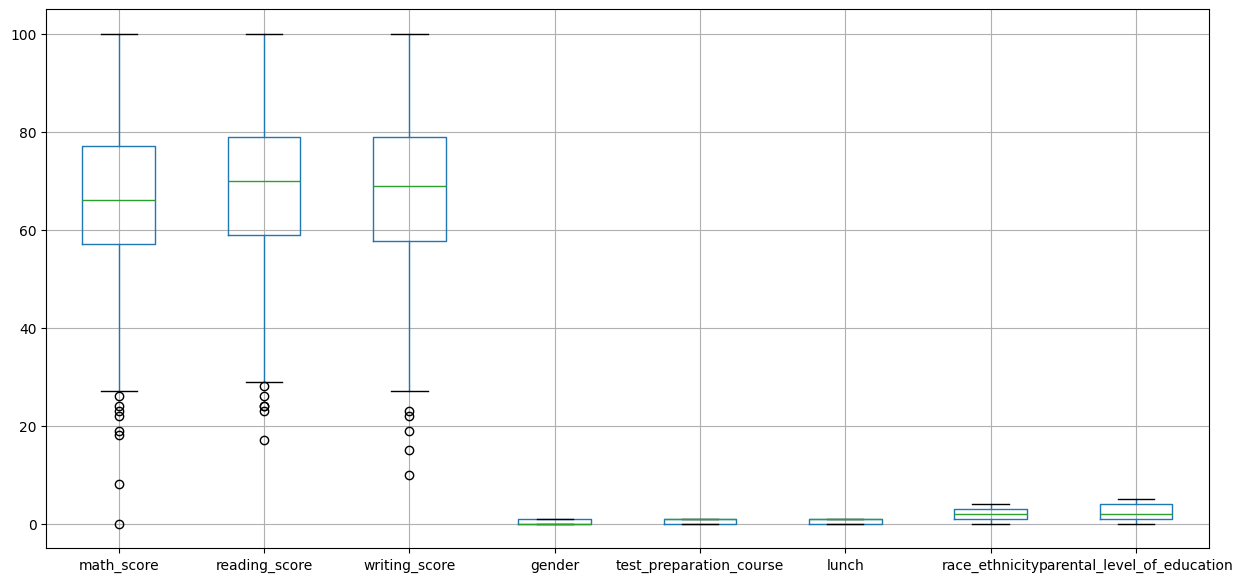

In [84]:
pd.plotting.boxplot(df,figsize=(15,7))
plt.show()

#### delete outlier

In [85]:
winsorized_math_score = winsorize(df['math_score'], limits=(0.008, 0.008))
winsorized_reading_score = winsorize(df['reading_score'], limits=(0.008, 0.008))
winsorized_writing_score = winsorize(df['writing_score'], limits=(0.008, 0.008))

In [86]:
df.drop(columns=["math_score"],inplace=True)
df.drop(columns=["reading_score"],inplace=True)
df.drop(columns=["writing_score"],inplace=True)

In [87]:
df["math_score"]=winsorized_math_score
df["reading_score"]=winsorized_reading_score
df["writing_score"]=winsorized_writing_score

#### check linearity

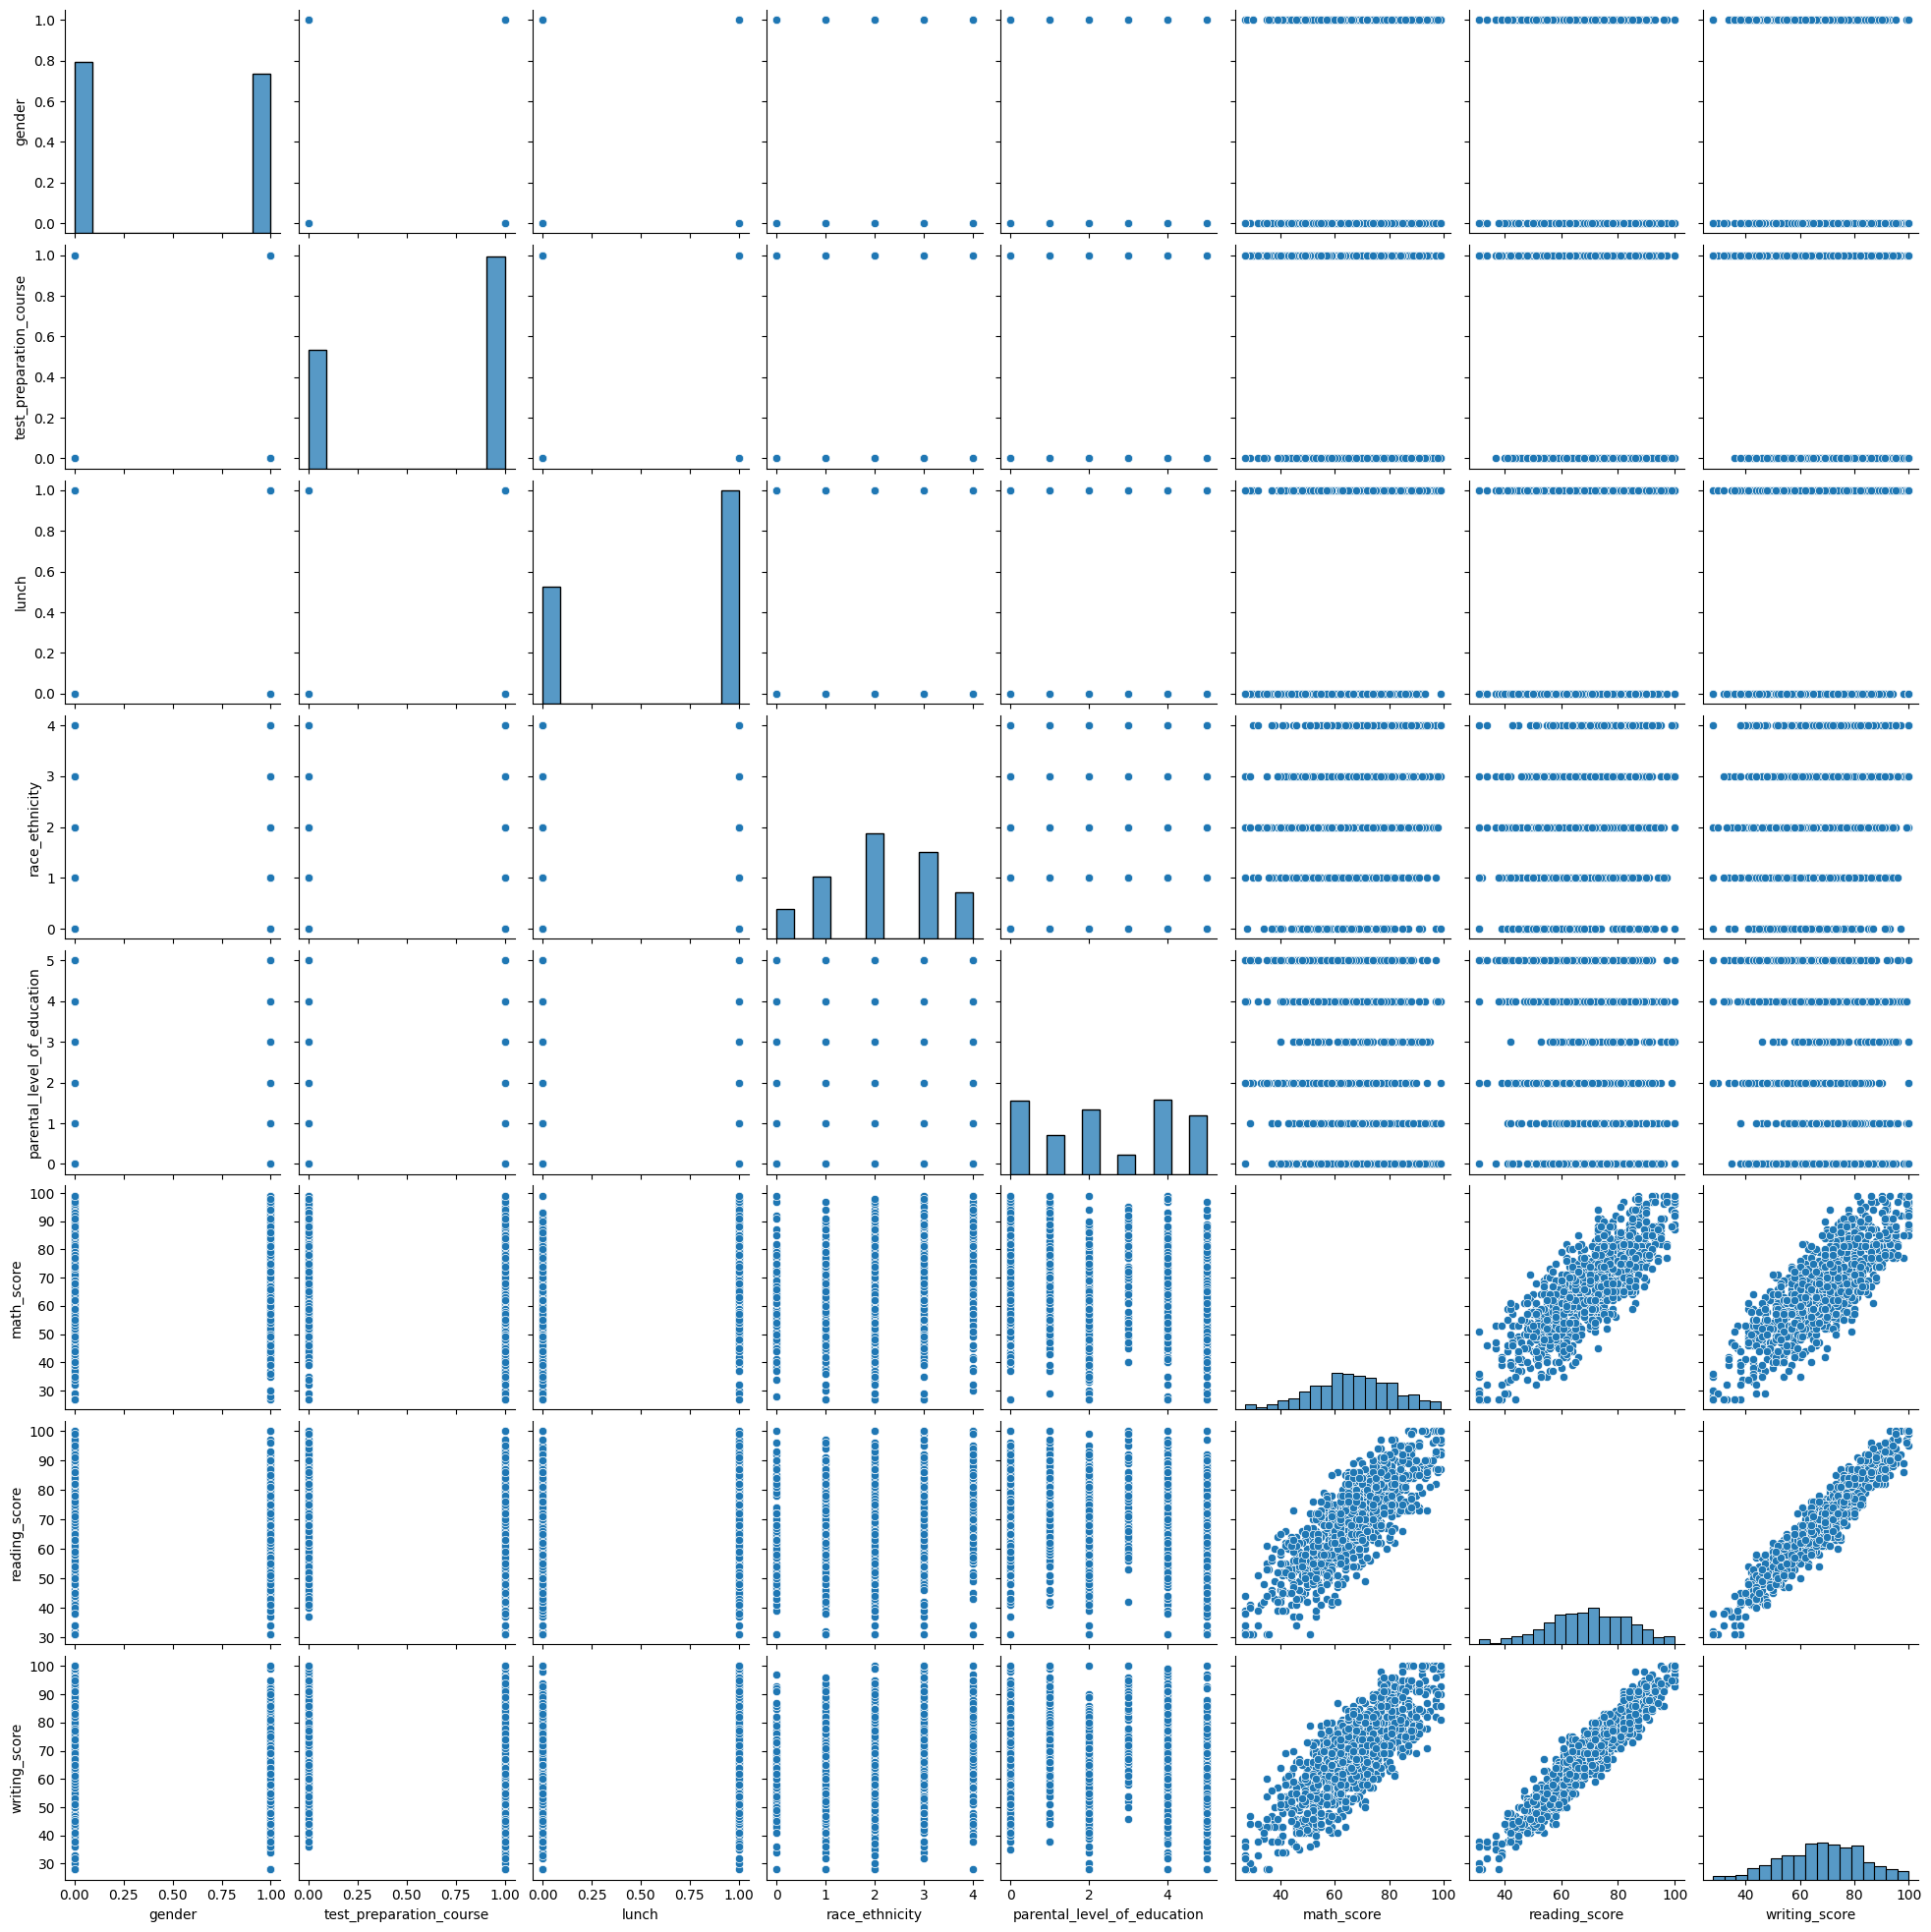

In [88]:
sns.pairplot(df)
plt.show()

#### handle no linear feature by kernel tricks

In [89]:
kpca=KernelPCA(n_components=3,kernel="rbf",gamma=1)
df[['pc1', 'pc2', 'pc3']]=kpca.fit_transform(df[["gender","test_preparation_course","race_ethnicity","parental_level_of_education"]])

In [90]:
df.drop(columns="parental_level_of_education",inplace=True)
df.drop(columns="race_ethnicity",inplace=True)
df.drop(columns="lunch",inplace=True)
df.drop(columns="test_preparation_course",inplace=True)
df.drop(columns="gender",inplace=True)

In [91]:
df.head()

,math_score,reading_score,writing_score,pc1,pc2,pc3
0,72,72,74,-0.219028,0.047796,-0.087957
1,69,90,88,0.327834,-0.044782,-0.235978
2,90,95,93,0.014554,0.137868,-0.188357
3,47,57,44,-0.053113,-0.043774,-0.031090
4,76,78,75,0.414448,-0.029116,-0.136327


#### multicolinearity

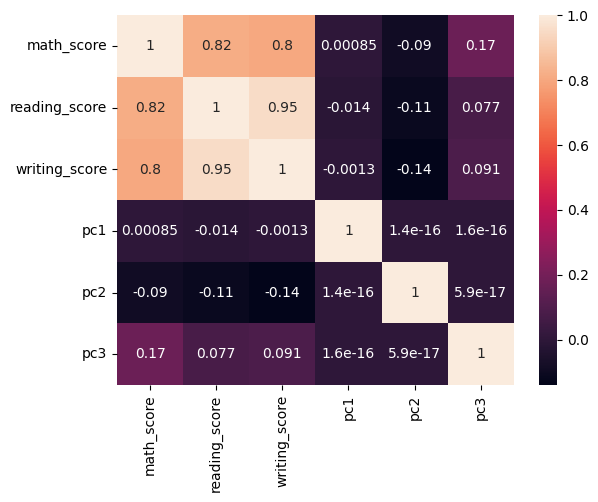

In [92]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [93]:
x=df[["pc1","pc2","pc3"]]
y=df[['math_score', 'reading_score', 'writing_score']]

In [94]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [95]:
sd=StandardScaler()
x_train_scaled = sd.fit_transform(x_train)
x_test_scaled = sd.transform(x_test)

In [96]:
lr=LinearRegression()
mor=MultiOutputRegressor(lr)
mor.fit(x_train_scaled,y_train)
y_pred=mor.predict(x_test_scaled)

In [97]:
for i, estimator in enumerate(mor.estimators_):
    print(f"Target {i}:")
    print(f"  Coefficients: {estimator.coef_}")
    print(f"  Intercept: {estimator.intercept_}")

Target 0:
  Coefficients: [ 0.2124202  -1.1189107   2.50629283]
  Intercept: 66.54
Target 1:
  Coefficients: [-0.19509059 -1.51065178  1.16841302]
  Intercept: 69.57875
Target 2:
  Coefficients: [-0.10084694 -2.05062278  1.33524475]
  Intercept: 68.4825


In [98]:
r2_score(y_test,y_pred)


0.019451483911765505

In [99]:
mean_absolute_percentage_error(y_test,y_pred)

0.21601267213190753

In [ ]:
mlflow.set_experiment("study_performance")
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
with mlflow.start_run():  
    mlflow.log_artifact("study_performance.csv",artifact_path="dataset")
    mlflow.log_input(mlflow.data.from_pandas(df, name="study_performance"))    
    mlflow.log_metric("r2_score",r2_score(y_test,y_pred))
    mlflow.log_metric("mean_absolute_percentage_error",mean_absolute_percentage_error(y_test,y_pred))
    for i, estimator in enumerate(mor.estimators_):
        for id,cof in enumerate(estimator.coef_):
            mlflow.log_param("w"+str(id+1)+" of y"+ str(i+1),cof )
        mlflow.log_param("b"+str(i+1), estimator.intercept_)
    mlflow.sklearn.log_model(mor,"model")


c:\Users\rt\AppData\Local\Programs\Python\Python310\lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2025/06/12 23:29:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run incongruous-hare-987 at: http://127.0.0.1:5000/#/experiments/942377587707276390/runs/e1a92d0c34694271aebb728cc31c0ad0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/942377587707276390
